In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
from itertools import chain

In [5]:
def find_pathway_genes(data,shared_list):
    my_list = data.loc[data.Description.isin(shared_list)].geneID.str.split('/').tolist()
    genes = list(chain(*my_list))
    genes = list(set(genes))
    return genes

In [451]:
def shared_pathway(data, tissue1, tissue2):
    shared = pd.DataFrame(data.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
    shared['list_as_string'] = shared['tissue'].apply(lambda x: ','.join(map(str, x)))
    # shared = shared.drop('tissue',axis=1)#??????
    df = shared.loc[(shared.list_as_string.str.contains(f'{tissue1}')) & shared.list_as_string.str.contains(f'{tissue2}')]
    return df

In [9]:
group = pd.read_csv('/data1/DYY/bambu/288_group.csv',sep='\t')
group['tissue'] = group['Sample ID'].str[:3]#'

In [11]:
tissue = group.tissue.drop_duplicates().tolist()

# s2

In [43]:
for t in tissue:
    up = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc2_up_reg_genes.csv',sep='\t')
    up = up.loc[up['row'].str.startswith('ENSG')]
    down = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc2_down_reg_genes.csv',sep='\t')
    down = down.loc[down['row'].str.startswith('ENSG')]
    up_gene = up['row'].str.split('.',expand=True).iloc[:,0].tolist()
    down_gene = down['row'].str.split('.',expand=True).iloc[:,0].tolist()
    with open(f'/data1/DYY/bambu/desgene_up&down/{t}_up.txt','w') as f:
        for item in up_gene:
            f.write(f'{item}\n')
    with open(f'/data1/DYY/bambu/desgene_up&down/{t}_down.txt','w') as f:
        for item in down_gene:
            f.write(f'{item}\n')
    # break

In [183]:
ts_go_dict={}
ts_kegg_dict={}
for t in tissue:
    go_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_go_bp.csv',sep='\t')
    kegg_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_kegg.csv',sep='\t')
    go_data = go_data.loc[go_data['p.adjust']<0.05]
    kegg_data = kegg_data.loc[kegg_data['p.adjust']<0.05]
    ts_go_dict[t] = go_data
    ts_kegg_dict[t] = kegg_data

In [185]:
up_go_dict={}
down_go_dict={}
for t in tissue:
    up_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_up_go_bp.csv',sep='\t')
    up_data = up_data.loc[up_data['p.adjust']<0.05]
    up_go_dict[t] = up_data
    down_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_down_go_bp.csv',sep='\t')
    down_data = down_data.loc[down_data['p.adjust']<0.05]
    down_go_dict[t] = down_data

In [187]:
con_go_dict={}
sca_go_dict={}
for t in tissue:
    try:
        up_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_conv_go_bp.csv',sep='\t')
        up_data = up_data.loc[up_data['p.adjust']<0.05]
        con_go_dict[t] = up_data
    except:
        con_go_dict[t] = pd.DataFrame()
    try:
        down_data = pd.read_csv(f'/home/bwu4/bambu_data_kegg_go/{t}_scat_go_bp.csv',sep='\t')
        down_data = down_data.loc[down_data['p.adjust']<0.05]
        sca_go_dict[t] = down_data
    except:
        sca_go_dict[t]=pd.DataFrame()

In [431]:
conver_go = pd.read_csv('/home/bwu4/tmp_data_kegg_go/all_con_gene_go_bp.csv',sep='\t')

In [191]:
up_go_df = pd.concat(up_go_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
# up_kegg_df = pd.concat(up_kegg_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
down_go_df = pd.concat(down_go_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
# down_kegg_df = pd.concat(down_kegg_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)


In [383]:
con_go_df = pd.concat(con_go_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
sca_go_df = pd.concat(sca_go_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)


In [74]:
down_go_df.columns=['Down_'+x for x in down_go_df.columns]#).merge(con_go_df[['tissue','Description','']],on=['tissue','Description'])

In [80]:
down_go_df = down_go_df.rename(columns={'Down_tissue':'Tissue','Down_ID':'ID','Down_Description':'Description'})

In [82]:
con_go_df.columns = ['Con_'+x for x in con_go_df.columns]

In [84]:
con_go_df = con_go_df.rename(columns={'Con_tissue':'Tissue','Con_ID':'ID','Con_Description':'Description'})

In [90]:
down_go_df.merge(con_go_df,on=['Tissue','ID','Description']).sort_values('ID').to_csv('/data1/DYY/bambu/s2.csv',sep='\t',index=False)

In [397]:
down_go_df.loc[down_go_df.Description.isin(conver_go.Description)].to_csv('/data1/DYY/bambu/s2_all_con_go_path_intersect_with_down_go_df_in_each.csv',index=False)

In [423]:
conver_go.loc[:,'FC'] = conver_go.Count/(conver_go['BgRatio'].str.split('/',expand=True).iloc[:,0].astype(int))

# s3 s4

In [13]:
convert = pd.read_csv('/data1/DYY/bambu/CPM_transcript.txt',sep='\t')[['TXNAME','GENEID']]

In [14]:
convert = convert.loc[convert.GENEID.str.startswith('ENS')]

In [112]:
data_3 = pd.DataFrame(index=convert.GENEID.drop_duplicates())
for t in tissue:
    up = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc2_up_reg_genes.csv',sep='\t')
    down = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc2_down_reg_genes.csv',sep='\t')
    
    
    data_3.loc[data_3.index.isin(up.row),f'{t}_up'] = 1
    data_3.loc[data_3.index.isin(down.row),f'{t}_down'] = 1
    try:
        con = pd.read_csv(f'/data1/DYY/bambu/288_conver_scatt_gene_all_tis/{t}_con.txt',sep='\t',header=None)
        data_3.loc[data_3.index.isin(con[0]),f'{t}_con'] = 1
    except:
        continue
    try:
        sca = pd.read_csv(f'/data1/DYY/bambu/288_conver_scatt_gene_all_tis/{t}_sca.txt',sep='\t',header=None)
        data_3.loc[data_3.index.isin(sca[0]),f'{t}_sca'] = 1
    except:
        continue
    # break

In [17]:
gene_name = pd.read_csv('/data1/DYY/data/ensg_gene_name_drop_dupl.csv',sep='\t')

In [19]:
gene_name = gene_name.rename(columns={'1':'GENEID','7':'gene_name'})

In [134]:
data_3.loc[data_3.count(axis=1)>0].fillna(0).sort_values('BLA_up',ascending=False).reset_index().merge(gene_name).to_csv('/data1/DYY/bambu/s3.csv',sep='\t',index=False)

In [140]:
data_3 = data_3.loc[data_3.count(axis=1)>0]

In [146]:
data_4 = data_3.loc[:,(data_3.columns.str.contains('up')|data_3.columns.str.contains('down'))]

In [150]:
data_4_up = data_4.loc[:,data_4.columns.str.contains('up')]
data_4_down = data_4.loc[:,data_4.columns.str.contains('down')]
data_4_up.columns=[x[:3] for x in data_4_up.columns]
data_4_down.columns = [x[:3] for x in data_4_down.columns]

In [154]:
data_4_up = data_4_up.loc[data_4_up.count(axis=1)>0]

In [156]:
data_4_down = data_4_down.loc[data_4_down.count(axis=1)>0]

In [399]:
data_4_up.reset_index().merge(gene_name).fillna('FALSE').replace({1:'TRUE'}).to_csv('/data1/DYY/bambu/s4_up.csv',sep='\t')

In [401]:
data_4_down.reset_index().merge(gene_name).fillna('FALSE').replace({1:'TRUE'}).to_csv('/data1/DYY/bambu/s4_down.csv',sep='\t')

In [164]:
data_4_up.fillna('FALSE').replace({1:'TRUE'}).to_csv('/data1/DYY/bambu/s4_up.csv',sep='\t')

In [166]:
data_4_down.fillna('FALSE').replace({1:'TRUE'}).to_csv('/data1/DYY/bambu/s4_down.csv',sep='\t')

# s7

In [21]:
iso_tpm = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_trans_norm.counts.fn',sep='\t',index_col=0).T.reset_index().rename(columns={'index':'name'}).merge(group)

In [157]:
ts_iso_dict=pd.DataFrame(index=pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/all_tumor_specific.txt',header=None)[0])
ts_gene_dict=pd.DataFrame(index=convert.GENEID.drop_duplicates(),columns=tissue)

for t in tissue:
    iso_ts = pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/'+t,header=None)
    ts_tpm = iso_tpm.loc[((iso_tpm.Type=='Tumor') & (iso_tpm.tissue==t)),iso_ts[0]]
    ts_tpm = ts_tpm[ts_tpm>0].count()
    ts_iso_dict.loc[ts_tpm.index,t] = ts_tpm
    gene_tpm =  iso_tpm.loc[((iso_tpm.Type=='Tumor') & (iso_tpm.tissue==t)),iso_ts[0]].T.reset_index().rename(columns={'index':'TXNAME'}).merge(convert).groupby('GENEID').sum()
    ts_gene_dict.loc[gene_tpm.index,t] = (gene_tpm >0).sum(axis=1).tolist()
    # break

In [158]:
ts_iso_dict.loc[:,'Occurrence across cancers'] = ts_iso_dict.count(axis=1)
ts_gene_dict.loc[:,'Occurrence across cancers'] = ts_gene_dict.count(axis=1)

In [161]:
ts_iso_dict = ts_iso_dict.sort_values('Occurrence across cancers',ascending=False).reset_index().rename(columns={0:'TXNAME'}).merge(convert).fillna(0)

In [177]:
ts_gene_dict.loc[ts_gene_dict['Occurrence across cancers']>0].fillna(0).sort_values('Occurrence across cancers',ascending=False).to_csv('/data1/DYY/bambu/1208s9.csv',sep='\t')#.loc[ts_gene_dict.GENEID=='ENSG00000163913.14']

In [93]:
ts_iso_dict.iloc[:,1:11][ts_iso_dict.iloc[:,1:11]>0].count()

BLA    1287
BRE    2531
CER    2895
COL    1641
END    2125
STO    2048
LIV    4589
LUN    4044
REC     634
KID    2991
dtype: int64

In [373]:
gtf_file= pd.read_csv('/data1/DYY/bambu/extended_annotations.gtf',sep='\t',header=None)
gtf_file = gtf_file.loc[gtf_file[2]=='transcript']

In [377]:
gtf_file['TXNAME'] = gtf_file[8].str.split('"',expand=True).iloc[:,3]

In [393]:
ts_iso_dict.merge(gtf_file[['TXNAME',0,3,4]]).rename(columns={0:'Chrom',3:'Start',4:'End'}).to_csv('/data1/DYY/bambu/s7.csv',sep='\t',index=False)

# s8

In [49]:
gene_tpm = pd.read_csv('/data1/DYY/bambu/288_count_matrix_deseq2/all_norm.counts.fn',sep='\t',index_col=0).T.reset_index().rename(columns={'index':'name'}).merge(group)

In [63]:
ts_gene_df = pd.DataFrame(index=convert.GENEID.drop_duplicates())
for t in tissue:
    ts_trans = pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/'+t,header=None)
    # ts_gene = pd.DataFrame(ts_iso_dict[t]).dropna().reset_index().rename(columns={0:'TXNAME'}).merge(convert).drop_duplicates('GENEID').GENEID
    ts_gene = convert.loc[convert.TXNAME.isin(ts_trans[0])].GENEID.drop_duplicates().tolist()
    ts_tpm = gene_tpm.loc[((gene_tpm.Type=='Tumor') & (iso_tpm.tissue==t)),ts_gene]
    ts_tpm = ts_tpm[ts_tpm>0].count()
    ts_gene_df.loc[ts_tpm.index,t] = ts_tpm
    # ts_gene_df.loc[ts_gene,t]=1

In [65]:
ts_gene_df = ts_gene_df[ts_gene_df.count(axis=1)>0]

In [66]:
ts_gene_df.loc[:,'Occurrence across cancers'] = ts_gene_df.count(axis=1)

In [300]:
ts_gene_df.sort_values('Occurrence across cancers',ascending=False).reset_index().merge(gene_name).fillna(0).to_csv('/data1/DYY/bambu/s8.csv',sep='\t',index=False)

# s9

In [173]:
ts_go_df.to_csv('/data1/DYY/bambu/s9_go.csv',sep='\t',index=False)
ts_kegg_df.to_csv('/data1/DYY/bambu/s9_kegg.csv',sep='\t',index=False)

In [473]:
ts_go_df = pd.concat(ts_go_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
# up_kegg_df = pd.concat(up_kegg_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)
ts_kegg_df = pd.concat(ts_kegg_dict).reset_index().rename(columns={'level_0':'tissue'}).drop('level_1',axis=1)

In [175]:
up_go_df.merge(conver_go,on='ID')

NameError: name 'conver_go' is not defined

In [20]:
down_go_df.merge(conver_go,on='ID').groupby('tissue').count()

,ID,Description_x,GeneRatio_x,BgRatio_x,pvalue_x,p.adjust_x,qvalue_x,geneID_x,Count_x,Description_y,GeneRatio_y,BgRatio_y,pvalue_y,p.adjust_y,qvalue_y,geneID_y,Count_y
tissue,,,,,,,,,,,,,,,,,
BLA,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26
BRE,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59,59
COL,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
KID,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84,84
LIV,80,80,80,80,80,80,80,80,80,80,80,80,80,80,80,80,80
LUN,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
STO,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [40]:
down_go_df.rename(columns={'GeneRatio':'down_gene_ratio','BgRatio':'down_bgratio','pvalue':'down_pvalue','p.adjust':'down_p.adjust','qvalue':'down_qvalue','geneID':'down_geneid','count':'down_count'}).merge(conver_go.drop(['Description'],axis=1).rename(columns={'GeneRatio':'con_gene_ratio','BgRatio':'con_bgratio','pvalue':'con_pvalue','p.adjust':'con_p.adjust','qvalue':'con_qvalue','geneID':'con_geneid','count':'con_count'}),on='ID').to_csv('/data1/DYY/data/shared_deg/down_with_conv_go_pathway.csv',sep='\t',index=False)

In [316]:
tissue= group['Sample ID'].str[:3].drop_duplicates().tolist()

In [322]:
group.tissue = group['Sample ID'].str[:3]

In [342]:
shared = pd.DataFrame(up_go_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
shared['list_as_string'] = shared['tissue'].apply(lambda x: ','.join(map(str, x)))
shared = shared.drop('tissue',axis=1)#??????
# df = shared.loc[(shared.list_as_string.str.contains(f'{tissue1}')) & shared.list_as_string.str.contains(f'{tissue2}')]

In [455]:
share_pathway = pd.DataFrame(index=tissue,columns=tissue)
for t1 in tissue:
    for t2 in tissue:
        up_share = shared_pathway(up_go_df,t1,t2)
        down_share = shared_pathway(down_go_df,t1,t2)
        share_pathway.loc[t1,t2] = [len(up_share),len(down_share)]

In [456]:
df = pd.DataFrame(share_pathway)

# Summing the elements of the lists
df_summed = df.applymap(lambda x: sum(x) if isinstance(x, list) else x)

# import ace_tools as tools; tools.display_dataframe_to_user(name="Summed Pathway DataFrame", dataframe=df_summed)

In [469]:
df

,BLA,BRE,CER,COL,END,STO,LIV,LUN,REC,KID
BLA,"[102, 420]","[88, 338]","[6, 101]","[9, 135]","[81, 27]","[10, 6]","[88, 26]","[30, 16]","[7, 15]","[46, 40]"
BRE,"[88, 338]","[298, 419]","[16, 73]","[23, 113]","[136, 25]","[2, 9]","[179, 44]","[42, 15]","[8, 11]","[162, 81]"
CER,"[6, 101]","[16, 73]","[42, 103]","[4, 52]","[0, 20]","[3, 0]","[0, 0]","[30, 1]","[0, 11]","[34, 3]"
COL,"[9, 135]","[23, 113]","[4, 52]","[52, 180]","[1, 23]","[6, 7]","[3, 29]","[6, 6]","[3, 15]","[40, 24]"
END,"[81, 27]","[136, 25]","[0, 20]","[1, 23]","[141, 28]","[0, 0]","[139, 0]","[26, 1]","[5, 3]","[45, 2]"
STO,"[10, 6]","[2, 9]","[3, 0]","[6, 7]","[0, 0]","[10, 32]","[1, 22]","[3, 2]","[2, 2]","[3, 30]"
LIV,"[88, 26]","[179, 44]","[0, 0]","[3, 29]","[139, 0]","[1, 22]","[194, 116]","[27, 13]","[5, 2]","[55, 56]"
LUN,"[30, 16]","[42, 15]","[30, 1]","[6, 6]","[26, 1]","[3, 2]","[27, 13]","[65, 23]","[2, 0]","[58, 4]"
REC,"[7, 15]","[8, 11]","[0, 11]","[3, 15]","[5, 3]","[2, 2]","[5, 2]","[2, 0]","[8, 17]","[3, 3]"
KID,"[46, 40]","[162, 81]","[34, 3]","[40, 24]","[45, 2]","[3, 30]","[55, 56]","[58, 4]","[3, 3]","[214, 145]"


In [461]:
df_summed

,BLA,BRE,CER,COL,END,STO,LIV,LUN,REC,KID
BLA,522,426,107,144,108,16,114,46,22,86
BRE,426,717,89,136,161,11,223,57,19,243
CER,107,89,145,56,20,3,0,31,11,37
COL,144,136,56,232,24,13,32,12,18,64
END,108,161,20,24,169,0,139,27,8,47
STO,16,11,3,13,0,42,23,5,4,33
LIV,114,223,0,32,139,23,310,40,7,111
LUN,46,57,31,12,27,5,40,88,2,62
REC,22,19,11,18,8,4,7,2,25,6
KID,86,243,37,64,47,33,111,62,6,359


In [465]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

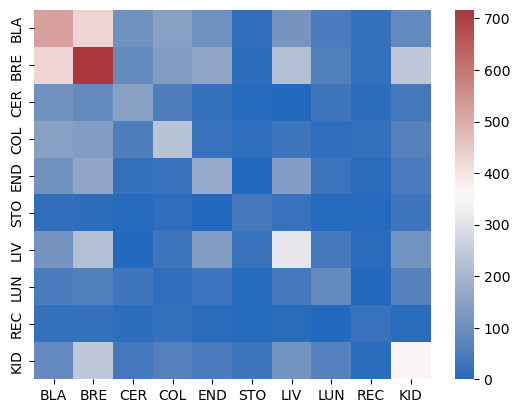

In [466]:
sns.heatmap(df_summed,cmap='vlag')
plt.savefig('/data1/DYY/bambu/plot/shared_desg_updown_pathway_count.pdf',dpi=400)

In [193]:
up_shared = pd.DataFrame(up_go_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
up_shared['list_as_string'] = up_shared['tissue'].apply(lambda x: ','.join(map(str, x)))
up_shared = up_shared.drop('tissue',axis=1)
# up_shared.loc[up_shared.list_as_string.str.contains('BLA,BRE')].to_csv('/data1/DYY/bambu/shared_deg/BLA_BRE_shared_up_go_pathway.csv',sep='\t')

down_shared = pd.DataFrame(down_go_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
down_shared['list_as_string'] = down_shared['tissue'].apply(lambda x: ','.join(map(str, x)))
down_shared = down_shared.drop('tissue',axis=1)
# down_shared.loc[down_shared.list_as_string.str.contains('BLA,BRE')].to_csv('/data1/DYY/bambu/shared_deg/BLA_BRE_shared_down_go_pathway.csv',sep='\t')

up_go_genes = pd.unique(pd.DataFrame(up_go_df.loc[(up_go_df.Description.isin(up_shared.loc[up_shared.list_as_string.str.contains('BLA,BRE')].index)) & ( up_go_df.tissue.isin(['BLA','BRE']))]['geneID'].str.split('/',expand=True)).values.ravel('K'))
up_go_genes = [x for x in up_go_genes if x is not None]

print(len(up_go_genes))

down_go_genes = pd.unique(pd.DataFrame(down_go_df.loc[(down_go_df.Description.isin(down_shared.loc[down_shared.list_as_string.str.contains('BLA,BRE')].index)) & ( down_go_df.tissue.isin(['BLA','BRE']))]['geneID'].str.split('/',expand=True)).values.ravel('K'))
down_go_genes = [x for x in down_go_genes if x is not None]
print(len(down_go_genes))

169
723


In [243]:
up_go_df.loc[:,'FC'] = up_go_df.Count/(up_go_df.BgRatio.apply(lambda x:x.split('/')[0]).astype(int))
down_go_df.loc[:,'FC'] = down_go_df.Count/(down_go_df.BgRatio.apply(lambda x:x.split('/')[0]).astype(int))

In [195]:
up_shared

,list_as_string
Description,
B cell activation,"BRE,CER,KID,LUN"
B cell differentiation,"BRE,KID"
B cell mediated immunity,"CER,KID,LUN"
B cell receptor signaling pathway,"CER,KID,LUN"
DNA conformation change,"BRE,END,LIV"
...,...
telomere organization,"BRE,LIV"
tissue homeostasis,"COL,KID"
tissue remodeling,"COL,KID"


In [18]:
for t in tissue:
    down = len(down_go_dict[t][down_go_dict[t].Description.str.contains('positive regulation')])
    print(f'{t} down:{down}')
    
    print(len(up_go_dict[t][up_go_dict[t].Description.str.contains('positive regulation')]))

COL down:4
5
STO down:0
35
REC down:0
2
LUN down:25
8
CER down:0
0
END down:0
0
LIV down:43
14
BRE down:40
78
BLA down:27
5
KID down:6
143


In [61]:
bla_genes = find_pathway_genes(ts_go_dict['BLA'],bla_bre_shared)

NameError: name 'bla_bre_shared' is not defined

In [48]:
bla_genes = find_pathway_genes(ts_go_dict['BLA'],bla_bre_shared)

In [49]:
bre_genes = find_pathway_genes(ts_go_dict['BRE'],bla_bre_shared)

In [101]:
sto_genes = find_pathway_genes(ts_go_dict['STO'],kid_sto_shared)

In [97]:
kid_up = pd.read_csv('/home/bwu4/tmp_data_kegg_go/KID_up_go_bp.csv',sep='\t')
kid_up = kid_up.loc[kid_up['p.adjust']<0.05]

In [215]:
bla_up = pd.read_csv('/home/bwu4/bambu_data_kegg_go/BLA_up_go_bp.csv',sep='\t')
bla_up = bla_up.loc[bla_up['p.adjust']<0.05]
bre_up = pd.read_csv('/home/bwu4/bambu_data_kegg_go/BRE_up_go_bp.csv',sep='\t')
bre_up = bre_up.loc[bre_up['p.adjust']<0.05]

In [323]:
bla_down = pd.read_csv('/home/bwu4/bambu_data_kegg_go/BLA_down_go_bp.csv',sep='\t')
bla_down = bla_down.loc[bla_down['p.adjust']<0.05]
bre_down = pd.read_csv('/home/bwu4/bambu_data_kegg_go/BRE_down_go_bp.csv',sep='\t')
bre_down = bre_down.loc[bre_down['p.adjust']<0.05]

In [195]:
kid_up_genes = find_pathway_genes(kid_up,kid_sto_shared)

NameError: name 'kid_up' is not defined

In [217]:
bla_up_genes = find_pathway_genes(bla_up,shared_pathway(up_go_df,'BLA','BRE').index.tolist())
bre_up_genes = find_pathway_genes(bre_up,shared_pathway(up_go_df,'BLA','BRE').index.tolist())

In [369]:
pivot_df = up_go_df.loc[(up_go_df.Description.isin(shared_pathway(up_go_df,'BLA','BRE').index) & (up_go_df.tissue.isin(['BLA','BRE'])))].pivot_table(index='Description', columns='tissue', values='FC', aggfunc='first')
for i in pivot_df.index.tolist():
    pivot_df.loc[i,'BLA_genes'] = ', '.join(find_pathway_genes(bla_up,[i]))
    pivot_df.loc[i,'BRE_genes'] = ', '.join(find_pathway_genes(bre_up,[i]))
    pivot_df.loc[i,'intersect_genes'] = ','.join(list((set(find_pathway_genes(bla_up,[i])).intersection(find_pathway_genes(bre_up,[i])))))
pivot_df.loc[:,'BLA_genes_count'] = pivot_df['BLA_genes'].apply(lambda x:len(x.split(',')))
pivot_df.loc[:,'BRE_genes_count'] = pivot_df['BRE_genes'].apply(lambda x:len(x.split(',')))
pivot_df.loc[:,'Intersection_genes_count'] = pivot_df['intersect_genes'].apply(lambda x:len(x.split(',')))
pivot_df.to_csv('/data1/DYY/bambu/shared_deg/sup_s5_BLA_BRE_shared_up_go_pathway.txt',sep='\t')

In [371]:
pivot_df.sort_values('Intersection_genes_count')

tissue,BLA,BRE,BLA_genes,BRE_genes,intersect_genes,BLA_genes_count,BRE_genes_count,Intersection_genes_count
Description,,,,,,,,
positive regulation of attachment of spindle microtubules to kinetochore,0.272727,0.363636,"AURKB, BIRC5, CCNB1","AURKB, CDCA8, BIRC5, CCNB1","AURKB,BIRC5,CCNB1",3,4,3
positive regulation of cell cycle checkpoint,0.157895,0.368421,"AURKB, MAD2L1, BIRC5","NDC80, CDCA8, PBK, GEN1, BIRC5, AURKB, MAD2L1","AURKB,MAD2L1,BIRC5",3,7,3
positive regulation of mitotic cell cycle spindle assembly checkpoint,0.250000,0.500000,"AURKB, MAD2L1, BIRC5","NDC80, CDCA8, GEN1, BIRC5, AURKB, MAD2L1","AURKB,MAD2L1,BIRC5",3,6,3
positive regulation of mitotic sister chromatid separation,0.222222,0.277778,"PRAP1, AURKB, DLGAP5, BIRC5","CDCA8, BIRC5, AURKB, DLGAP5, ESPL1","AURKB,DLGAP5,BIRC5",4,5,3
positive regulation of spindle checkpoint,0.250000,0.500000,"AURKB, MAD2L1, BIRC5","NDC80, CDCA8, GEN1, BIRC5, AURKB, MAD2L1","AURKB,MAD2L1,BIRC5",3,6,3
...,...,...,...,...,...,...,...,...
nuclear chromosome segregation,0.065421,0.183801,"SYCE3, UBE2C, BUB1B, NCAPH, BUB1, CCNE2, TTK, ...","ZWINT, KIF23, RACGAP1, UBE2C, KIF11, ESCO2, BU...","UBE2C,BUB1B,NCAPH,BUB1,CCNE2,TTK,ECT2,TRIP13,D...",21,59,19
mitotic nuclear division,0.067692,0.172308,"PKMYT1, UBE2C, BUB1B, TPX2, NCAPH, BUB1, MYBL2...","ZWINT, PKMYT1, KIF23, RACGAP1, UBE2C, KIF11, E...","PKMYT1,UBE2C,BUB1B,TPX2,NCAPH,BUB1,MYBL2,TTK,T...",22,56,20
mitotic cell cycle phase transition,0.050740,0.109937,"PKMYT1, UBE2C, BUB1B, BUB1, CCNE2, UBD, MELK, ...","ZWINT, PKMYT1, CLSPN, ORC1, UBE2C, CKS2, CCNB2...","PKMYT1,UBE2C,BUB1B,BUB1,CCNE2,MELK,TTK,TRIP13,...",24,52,21


In [373]:
pivot_df = down_go_df.loc[(down_go_df.Description.isin(shared_pathway(down_go_df,'BLA','BRE').index) & (down_go_df.tissue.isin(['BLA','BRE'])))].pivot_table(index='Description', columns='tissue', values='FC', aggfunc='first')
for i in pivot_df.index.tolist():
    pivot_df.loc[i,'BLA_genes'] = ','.join(find_pathway_genes(bla_down,[i]))
    pivot_df.loc[i,'BRE_genes'] = ','.join(find_pathway_genes(bre_down,[i]))
    pivot_df.loc[i,'intersect_genes'] = ','.join(list((set(find_pathway_genes(bla_down,[i])).intersection(find_pathway_genes(bre_down,[i])))))
pivot_df.loc[:,'BLA_genes_count'] = pivot_df['BLA_genes'].apply(lambda x:len(x.split(',')))
pivot_df.loc[:,'BRE_genes_count'] = pivot_df['BRE_genes'].apply(lambda x:len(x.split(',')))
pivot_df.loc[:,'Intersection_genes_count'] = pivot_df['intersect_genes'].apply(lambda x:len(x.split(',')))

pivot_df.to_csv('/data1/DYY/bambu/shared_deg/sup_s5_BLA_BRE_shared_down_go_pathway.txt',sep='\t')

In [375]:
pivot_df.sort_values('Intersection_genes_count')

tissue,BLA,BRE,BLA_genes,BRE_genes,intersect_genes,BLA_genes_count,BRE_genes_count,Intersection_genes_count
Description,,,,,,,,
ventricular cardiac muscle cell membrane repolarization,0.172414,0.172414,"ANK2,KCNH2,KCNE4,KCNJ8,KCND3","ANK2,SCN4B,SCN2B,KCNE1,LOC102723475",ANK2,5,5,1
membrane repolarization during action potential,0.193548,0.129032,"KCNH2,FLNA,KCNE4,KCNJ8,CAV1,KCND3","LOC102723475,SCN2B,KCNE1,CAV1",CAV1,6,4,1
activation of adenylate cyclase activity,0.178571,0.142857,"VIPR2,ADCYAP1,EDNRA,ADRB3,CAP2","LHCGR,ADRB1,ADRB2,AVPR2",,5,4,1
cardiac muscle cell membrane repolarization,0.150000,0.125000,"ANK2,KCNH2,FLNA,KCNE4,KCNJ8,KCND3","ANK2,SCN4B,SCN2B,KCNE1,LOC102723475",ANK2,6,5,1
positive regulation of heart contraction,0.175000,0.150000,"AVPR1A,CCN2,TGFB2,TPM1,RGS2,HRC,ATP1A2","SCN3B,ADRA1A,ADRB1,HRC,ATP1A2,EDN3","HRC,ATP1A2",7,6,2
...,...,...,...,...,...,...,...,...
regulation of epithelial cell proliferation,0.094203,0.077295,"TNMD,ANG,GLI1,AGTR1,FGF9,KLF9,NR4A3,FZD7,BMP5,...","TNMD,GPC3,PTN,ZFP36,AGTR1,KLF9,NR4A3,BMP5,LIMS...","LIMS2,OSR2,PGR,CAV1,FGF2,TNMD,GPBAR1,AGTR1,EGR...",39,32,18
vascular process in circulatory system,0.166667,0.111111,"TACR2,SLC16A2,SLC8A1,CLDN5,PDE2A,AGTR1,ADRA2A,...","CLDN5,PDE2A,AGTR1,ADRA2A,HBB,SLC29A4,KCNMB2,CA...","CAV1,NPR1,AKAP12,KLF2,PDE2A,CLDN5,ATP1B2,AGTR1...",45,30,18
muscle contraction,0.213675,0.099715,"PTGER3,CASQ2,SCN7A,GSN,APBB1,TACR2,SLC8A1,MYL3...","PTGER3,CASQ2,SCN7A,GSN,SCN4B,MYL3,KCNE1,ADRA2A...","PTGER3,CASQ2,GSN,SCN7A,MYL3,ADRA2A,DMD,HRC,MYO...",75,35,20


In [253]:
len(bre_up_genes)

152

In [255]:
len(bla_up_genes)

62

In [108]:
len(pd.DataFrame(kid_genes).merge(pd.DataFrame(kid_up_genes)).merge(pd.DataFrame(sto_genes)))

26

In [205]:
len(find_pathway_genes(bla_up,shared_pathway(up_go_df,'BLA','BRE').index.tolist()))

62

# 3f

In [597]:
share_pathway = pd.DataFrame(index=tissue,columns=tissue)
for t1 in tissue:
    for t2 in tissue:
        up_share = shared_pathway(ts_go_df,t1,t2)
        # down_share = shared_pathway(ts_kegg_df,t1,t2)
        # share_pathway.loc[t1,t2] = [len(up_share),len(down_share)]
        share_pathway.loc[t1,t2] = len(up_share)

In [599]:
share_pathway

,BLA,BRE,CER,COL,END,STO,LIV,LUN,REC,KID
BLA,3,0,2,0,1,0,3,0,0,0
BRE,0,28,4,0,15,0,23,0,0,6
CER,2,4,78,0,6,4,32,0,0,52
COL,0,0,0,0,0,0,0,0,0,0
END,1,15,6,0,40,0,36,0,0,6
STO,0,0,4,0,0,7,0,0,0,7
LIV,3,23,32,0,36,0,79,1,0,19
LUN,0,0,0,0,0,0,1,4,0,4
REC,0,0,0,0,0,0,0,0,0,0
KID,0,6,52,0,6,7,19,4,0,75


In [601]:
df = pd.DataFrame(share_pathway)
df_summed = df.applymap(lambda x: sum(x) if isinstance(x, list) else x)

In [564]:
kid_cer_shared = shared_pathway(ts_go_df,'KID','CER').drop('tissue',axis=1)

In [566]:
ts_go_df.head()

,tissue,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
0,BLA,GO:0071897,DNA biosynthetic process,28/938,198/18903,5.618490e-07,0.002736,0.002668,CHEK1/GINS1/MAD2L2/MYC/EXOSC10/TFDP1/PDGFB/REV...,28
1,BLA,GO:0006260,DNA replication,32/938,286/18903,1.542887e-05,0.037562,0.036631,ACTR5/CHEK1/DONSON/BRCA2/GINS1/RNASEH2A/SIN3A/...,32
2,BLA,GO:2000278,regulation of DNA biosynthetic process,18/938,121/18903,2.875776e-05,0.046674,0.045518,CHEK1/GINS1/MYC/EXOSC10/TFDP1/PDGFB/CCT3/RFC4/...,18
3,BRE,GO:0000819,sister chromatid segregation,43/1459,239/18903,1.477186e-07,0.000755,0.000697,MAD1L1/BIRC5/UBE2C/KIF11/ZWINT/HORMAD1/MACROH2...,43
4,BRE,GO:0000070,mitotic sister chromatid segregation,38/1459,204/18903,3.107703e-07,0.000755,0.000697,MAD1L1/BIRC5/UBE2C/KIF11/ZWINT/MACROH2A1/KIF14...,38


In [588]:
test = ts_go_df.set_index('Description').loc[(kid_cer_shared.index) ]
kid_cer_shared.loc[:,'Genes enriched in each GO pathway in KID'] = test.loc[test.tissue=='KID'].geneID
kid_cer_shared.loc[:,'Genes enriched in each GO pathway in CER'] =test.loc[test.tissue=='CER'].geneID
kid_cer_shared['Genes enriched in each GO pathway in KID'] = kid_cer_shared['Genes enriched in each GO pathway in KID'].apply(lambda x: x.split('/'))
kid_cer_shared['Genes enriched in each GO pathway in CER'] = kid_cer_shared['Genes enriched in each GO pathway in CER'].apply(lambda x: x.split('/'))
kid_cer_shared['Number of Commonly Enriched Genes in Both Tumors'] = kid_cer_shared.apply(
    lambda row: len(set(row['Genes enriched in each GO pathway in KID']) & set(row['Genes enriched in each GO pathway in CER'])),
    axis=1
)

In [594]:
kid_cer_shared.sort_values('Number of Commonly Enriched Genes in Both Tumors',ascending=False).to_csv('/data1/DYY/bambu/s11.csv')

<Axes: >

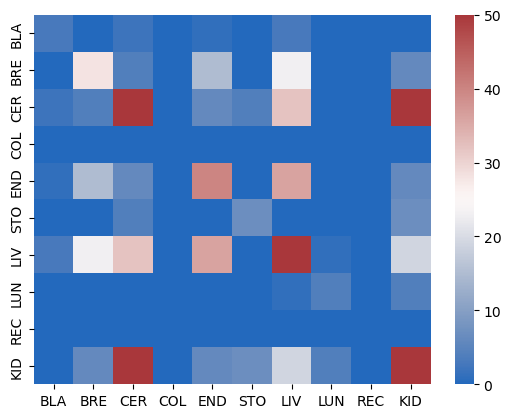

In [603]:
sns.heatmap(df_summed,cmap='vlag',vmax=50)
plt.savefig('/data1/DYY/bambu/plot/shared_ts_pathway_count.pdf',dpi=400)

In [418]:
up_shared

,list_as_string
Description,
DNA biosynthetic process,"BLA,CER,LIV"
DNA conformation change,"BRE,CER,LIV"
DNA duplex unwinding,"BRE,CER,KID,LIV"
DNA geometric change,"BRE,CER,LIV"
DNA recombination,"CER,END,LIV"
...,...
stress-activated protein kinase signaling cascade,"KID,LIV"
synapse organization,"KID,LIV,LUN"
telomere maintenance,"CER,LIV"


In [416]:
up_shared = pd.DataFrame(ts_go_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
up_shared['list_as_string'] = up_shared['tissue'].apply(lambda x: ','.join(map(str, x)))
up_shared = up_shared.drop('tissue',axis=1)
up_shared.loc[(up_shared.list_as_string.str.contains('KID')) & (up_share.list_as_string.str.contains('CER'))].to_csv('/data1/DYY/bambu/shared_deg/KID_CER_shared_ts_go_pathway.csv',sep='\t')

down_shared = pd.DataFrame(ts_kegg_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('tissue').groupby('Description')['tissue'].apply(list))
down_shared['list_as_string'] = down_shared['tissue'].apply(lambda x: ','.join(map(str, x)))
down_shared = down_shared.drop('tissue',axis=1)
down_shared.loc[(down_shared.list_as_string.str.contains('KID')) & (down_shared.list_as_string.str.contains('CER'))].to_csv('/data1/DYY/bambu/shared_deg/KID_CER_shared_ts_kegg_pathway.csv',sep='\t')

up_go_genes = pd.unique(pd.DataFrame(ts_go_df.loc[ts_go_df.Description.isin(up_shared.loc[(up_shared.list_as_string.str.contains('KID')) & (up_share.list_as_string.str.contains('CER'))].index)]['geneID'].str.split('/',expand=True)).values.ravel('K'))
up_go_genes = [x for x in up_go_genes if x is not None]

print(len(up_go_genes))

down_go_genes = pd.unique(pd.DataFrame(ts_kegg_df.loc[ts_kegg_df.Description.isin(down_shared.loc[(down_shared.list_as_string.str.contains('KID')) & (down_shared.list_as_string.str.contains('CER'))].index)]['geneID'].str.split('/',expand=True)).values.ravel('K'))
down_go_genes = [x for x in down_go_genes if x is not None]
print(len(down_go_genes))

869
57


In [20]:
go_df = pd.concat(ts_go_dict).reset_index().drop('level_1',axis=1)
kegg_df = pd.concat(ts_kegg_dict).reset_index().drop('level_1',axis=1)

In [32]:
go_df.to_csv('/data1/DYY/data/tumor_spec_go_df.csv',sep='\t',index=False)
kegg_df.to_csv('/data1/DYY/data/tumor_spec_kegg_df.csv',sep='\t',index=False)

In [39]:
pd.set_option('display.max_rows',100)

In [65]:
test = pd.DataFrame(go_df.groupby('ID').filter(lambda x:len(x)>1).sort_values('level_0').groupby('Description')['level_0'].apply(list))#.groupby('level_0').count()

In [215]:
len(up_shared.loc[up_shared.list_as_string.str.contains('BLA,BRE')])

88

In [213]:
len(down_shared.loc[down_shared.list_as_string.str.contains('BLA,BRE')])

338

In [313]:
test_up_go_df = up_go_df.loc[(up_go_df.Description.isin(up_shared.loc[up_shared.list_as_string.str.contains('BLA,BRE')].index)) & ( up_go_df.tissue.isin(['BLA','BRE']))]
test_df = pd.DataFrame(index=test_up_go_df.Description.drop_duplicates())
for k,v in test_up_go_df.groupby('Description'):
    test_genes = pd.unique(v.geneID.str.split('/',expand=True).values.ravel('K'))
    test_genes = [x for x in test_genes if x is not None]
    test_df.loc[k,'shared_genes'] = len(test_genes)
    # break

In [309]:
test_down_go_df = down_go_df.loc[(down_go_df.Description.isin(down_shared.loc[down_shared.list_as_string.str.contains('BLA,BRE')].index)) & ( down_go_df.tissue.isin(['BLA','BRE']))]
test_df = pd.DataFrame(index=test_down_go_df.Description.drop_duplicates())
for k,v in test_down_go_df.groupby('Description'):
    test_genes = pd.unique(v.geneID.str.split('/',expand=True).values.ravel('K'))
    test_genes = [x for x in test_genes if x is not None]
    test_df.loc[k,'shared_genes'] = len(test_genes)
    # break

In [48]:
ls1 = find_pathway_genes(ts_go_dict['CER'],['mitotic recombination'])
ls2 = find_pathway_genes(ts_go_dict['LIV'],['mitotic recombination'])
ls3 = find_pathway_genes(ts_go_dict['KID'],['mitotic recombination'])

In [56]:
set(ls1).intersection(ls2).intersection(ls3)

{'ERCC2', 'GEN1', 'RAD51C'}

In [159]:
df = go_df.rename(columns={'level_0':'tissue'})[['tissue','Description','p.adjust','GeneRatio','Count']]
df["GeneRatio"] = go_df.GeneRatio.str.split('/',expand=True).iloc[:,0].astype(int)/go_df.BgRatio.str.split('/',expand=True).iloc[:,0].astype(int)
wide_df = df.pivot(index="Description", columns="tissue", values="GeneRatio")
wide_df = wide_df.loc[wide_df.count(axis=1)>2]
wide_df['sums'] = wide_df.count(axis=1)
wide_df.sort_values('sums',ascending=False).head(20).drop('sums',axis=1).fillna(0).to_csv('/data1/DYY/bambu/3f_data_generatio.csv',sep='\t')
wide_df_p_df = df.pivot(index="Description", columns="tissue", values="p.adjust")
wide_df_p_df = wide_df_p_df.loc[wide_df_p_df.count(axis=1)>2]
wide_df_p_df['sums'] = wide_df_p_df.count(axis=1)
wide_df_p_df.sort_values('sums',ascending=False).head(20).drop('sums',axis=1).fillna(1).to_csv('/data1/DYY/bambu/3f_data_p.csv',sep='\t')

In [72]:
bla_bre_shared = test_up_shared[test_up_shared.list_as_string=='BLA,BRE'].index.tolist()